# Quantile Regression Intervals (LightGBM)

Non-parametric 5%–95% predictive bands alongside the median.


Empirical 5-95 coverage=0.763  mean width=0.342


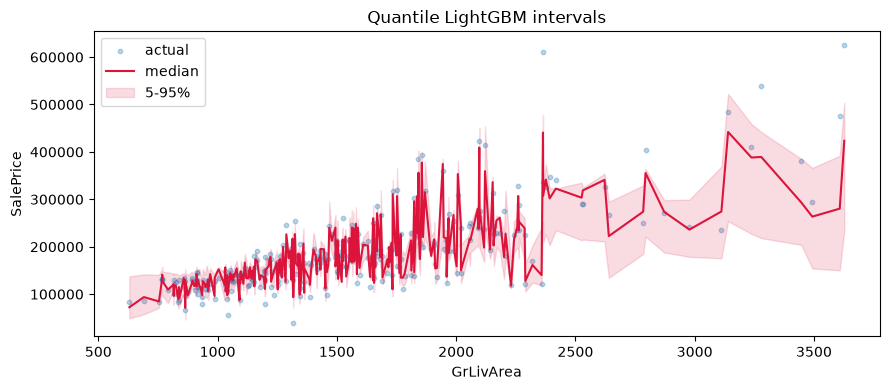

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import build_feature_frame, load_housing_data, QuantileLightGBM, train_val_split

train, _ = load_housing_data()
eng, _ = build_feature_frame(train, oof_target_encoding=True)
X_tr, X_va, y_tr, y_va = train_val_split(eng.X, eng.y, random_state=42)
q = QuantileLightGBM(n_estimators=500).fit(X_tr, y_tr, X_val=X_va, y_val=y_va)
lo, mid, hi = q.predict_intervals(X_va)
cov = np.mean((y_va >= lo) & (y_va <= hi))
print(f"Empirical 5-95 coverage={cov:.3f}  mean width={np.mean(hi-lo):.3f}")

# visualize vs living area if present
idx = eng.schema.feature_names.index("GrLivArea")
order = np.argsort(X_va[:, idx])
plt.figure(figsize=(9,4))
plt.scatter(X_va[:, idx], np.expm1(y_va), s=10, alpha=0.3, label="actual")
plt.plot(X_va[order, idx], np.expm1(mid[order]), color="crimson", label="median")
plt.fill_between(X_va[order, idx], np.expm1(lo[order]), np.expm1(hi[order]), color="crimson", alpha=0.15, label="5-95%")
plt.xlabel("GrLivArea"); plt.ylabel("SalePrice"); plt.legend()
plt.title("Quantile LightGBM intervals")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "quantile_intervals.png", dpi=120)
plt.show()
